# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Note groupe

A la suite de chaque cas de test 2 classes, on ajoute une cellule qui entraine **nos propres modeles** (`linear_model_csv.c` et `mlp_csv.c`, ecrits en C par l'equipe) sur les memes donnees `X`/`Y` que ci-dessus, et affiche le meme genre de nuage de points, mais colore par **notre prediction** (un contour noir marque les points que notre modele classe mal) -- pour voir directement si ca marche ou si ca merde.

In [ ]:
# --- Mise en place : compile nos modeles une fois, puis fonction reutilisable ---
import subprocess
from pathlib import Path

racine = Path.cwd()
while racine != racine.parent and not (racine / "preprocessing").exists():
    racine = racine.parent

chemin_lin = racine / "models" / "lineaire" / "linear_model_csv"
chemin_mlp = racine / "models" / "mlp" / "mlp_csv"
subprocess.check_call(["gcc", str(racine / "models" / "lineaire" / "linear_model_csv.c"), "-o", str(chemin_lin)], cwd=str(racine))
subprocess.check_call(["gcc", "-O2", str(racine / "models" / "mlp" / "mlp_csv.c"), "-o", str(chemin_mlp), "-lm"], cwd=str(racine))

def tester_nos_modeles(X, Y, titre):
    """Ecrit X/Y en CSV (labels -1/+1 -> 0/1), lance nos deux modeles C,
    affiche un nuage de points colore par la vraie classe."""
    tmp_csv = racine / "datasets" / "toy" / "_tmp_prof.csv"
    Y = np.asarray(Y).reshape(-1)
    lignes_csv = ["x1,x2,label"]
    for (x1, x2), y in zip(X, Y):
        lignes_csv.append(str(x1) + "," + str(x2) + "," + str(1 if y > 0 else 0))
    tmp_csv.write_text(chr(10).join(lignes_csv))

    sortie_lin = subprocess.check_output([str(chemin_lin), str(tmp_csv), "50", "0.1"], text=True, cwd=str(racine))
    lignes_acc_lin = [l for l in sortie_lin.strip().splitlines() if "accuracy=" in l]
    acc_lin = float(lignes_acc_lin[-1].split("accuracy=")[1]) if lignes_acc_lin else None

    sortie_mlp = subprocess.check_output([str(chemin_mlp), str(tmp_csv), "8", "1500", "0.3"], text=True, cwd=str(racine))
    lignes_acc_mlp = [l for l in sortie_mlp.strip().splitlines() if "accuracy_test=" in l]
    acc_mlp = float(lignes_acc_mlp[-1].split("accuracy_test=")[1]) if lignes_acc_mlp else None

    print(titre + " -- Linear: " + str(round(acc_lin, 3)) + " (" + ("OK" if acc_lin and acc_lin > 0.9 else "KO") + ")   MLP: " + str(round(acc_mlp, 3)) + " (" + ("OK" if acc_mlp and acc_mlp > 0.9 else "KO") + ")")

    plt.figure(figsize=(6, 5))
    couleurs = ["red" if y > 0 else "blue" for y in Y]
    plt.scatter(X[:, 0], X[:, 1], c=couleurs)
    plt.title(titre + " -- Linear=" + str(round(acc_lin, 2)) + "  MLP=" + str(round(acc_mlp, 2)))
    plt.show()
    plt.clf()
    return acc_lin, acc_mlp

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [3]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

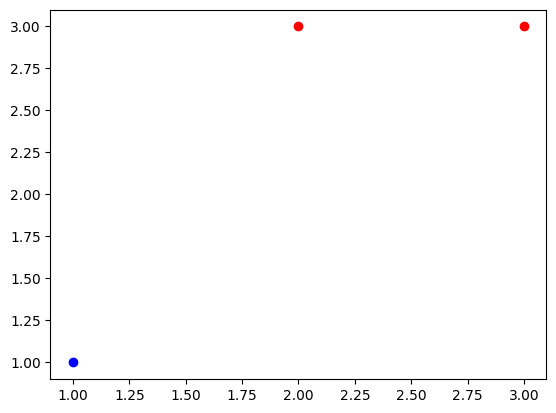

<Figure size 640x480 with 0 Axes>

In [4]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

Linear Simple -- Linear: 1.0 (OK)   MLP: 1.0 (OK)


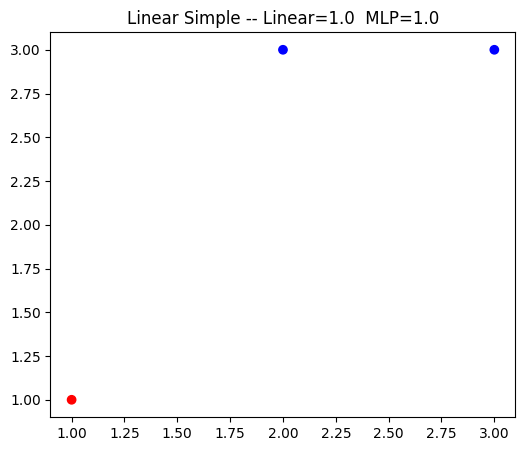

(1.0, 1.0)

<Figure size 640x480 with 0 Axes>

In [5]:
tester_nos_modeles(X, Y, "Linear Simple")

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [6]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

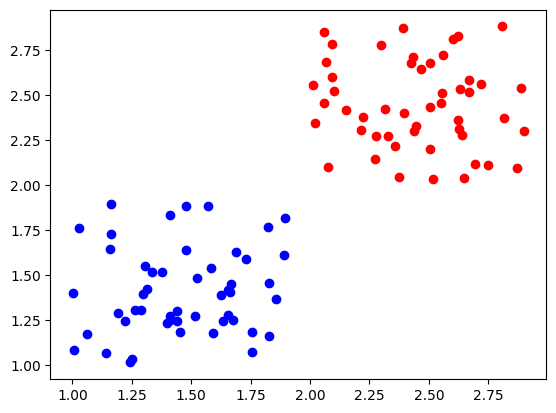

<Figure size 640x480 with 0 Axes>

In [7]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

Linear Multiple -- Linear: 1.0 (OK)   MLP: 1.0 (OK)


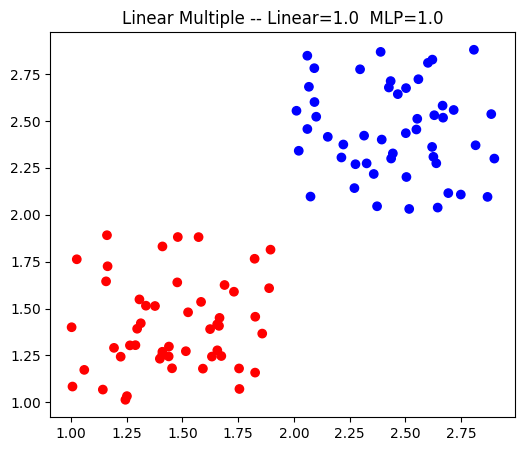

(1.0, 1.0)

<Figure size 640x480 with 0 Axes>

In [8]:
tester_nos_modeles(X, Y, "Linear Multiple")

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [9]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

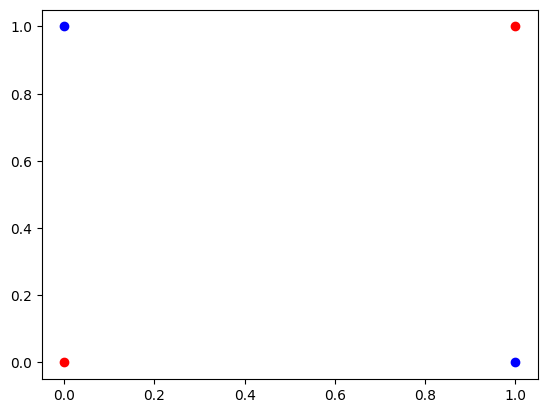

<Figure size 640x480 with 0 Axes>

In [10]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

XOR -- Linear: 0.5 (KO)   MLP: 1.0 (OK)


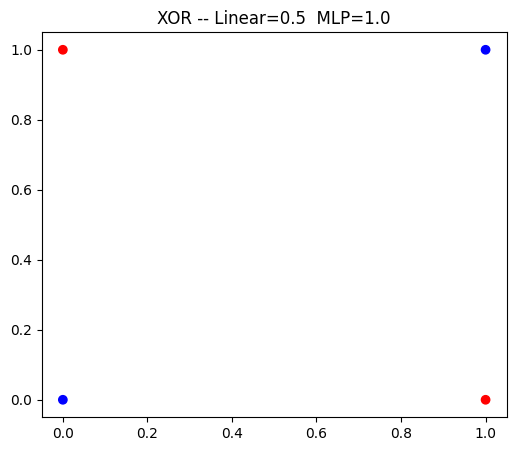

(0.5, 1.0)

<Figure size 640x480 with 0 Axes>

In [11]:
tester_nos_modeles(X, Y, "XOR")

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [12]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

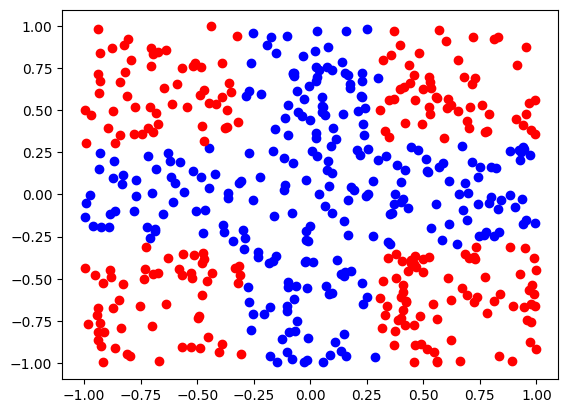

<Figure size 640x480 with 0 Axes>

In [13]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

Cross -- Linear: 0.51 (KO)   MLP: 1.0 (OK)


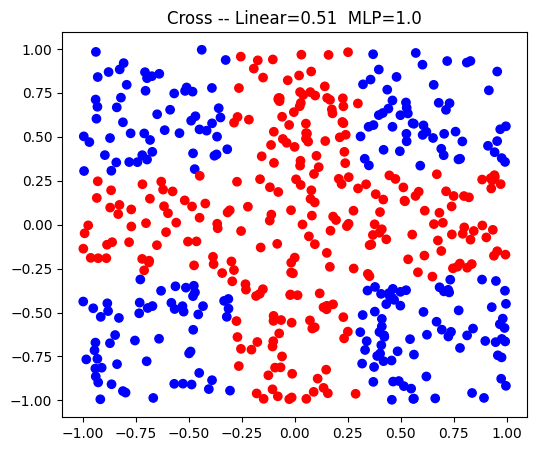

(0.51, 1.0)

<Figure size 640x480 with 0 Axes>

In [14]:
tester_nos_modeles(X, Y, "Cross")

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [15]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

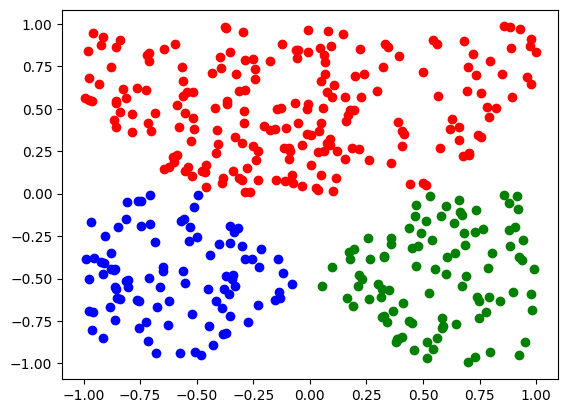

<Figure size 640x480 with 0 Axes>

In [16]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [17]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

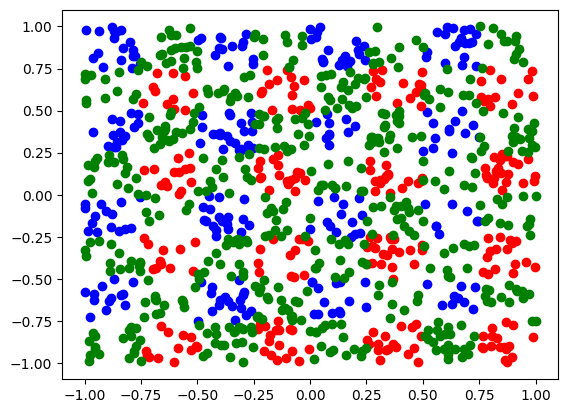

<Figure size 640x480 with 0 Axes>

In [18]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [19]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

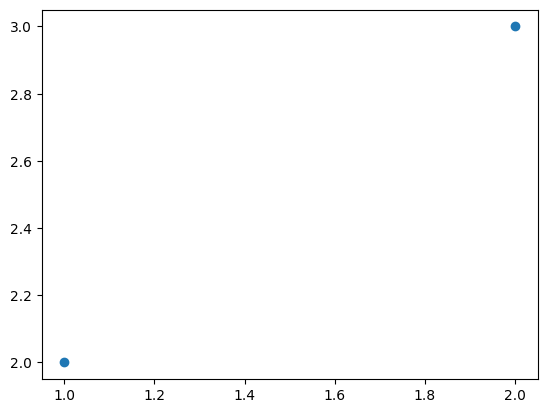

<Figure size 640x480 with 0 Axes>

In [20]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [21]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

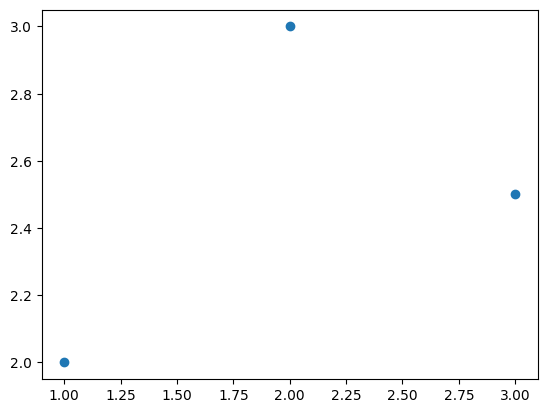

<Figure size 640x480 with 0 Axes>

In [22]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [23]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

In [24]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [25]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

In [26]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [27]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

In [28]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>